# Predicting Post-Graduation Outcomes from U.S. College Characteristics: A Comparative Study of Linear and Neural Network Models
### COMP 560 - Artificial Intelligence | Final Project
---
**Research Question:** Can we predict median student earnings 10 years after enrollment based on institutional features such as tuition cost, school type, enrollment size, and student debt load?

**Models:** Linear Regression (baseline) vs. Feedforward Neural Network (FFN)

**Dataset:** U.S. Department of Education - College Scorecard (2023)

## Reproducibility Notes
- All random seeds are set to 42 (torch, numpy, random)
- Pre-trained model weights are saved in `ffn_model.pt`, `lr_model.pkl`, `scaler.pkl`
- Running the notebook with "Run All" should reproduce paper results exactly
- To skip training and use saved models, run only the evaluation cells

## 1. Install & Import Libraries

In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries loaded!')

All libraries loaded!


In [8]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# For strict determinism (slight speed cost):
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Mount Google Drive & Load Dataset

In [9]:
import os
import pandas as pd
import numpy as np

# Columns we need (file has 3,214 total, only load these 12)
FEATURES_RAW = [
    'INSTNM',             # Institution name
    'CONTROL',            # School type (1=public, 2=private nonprofit, 3=for-profit)
    'UGDS',               # Undergrad enrollment
    'NPT4_PUB',           # Net price, public schools
    'NPT4_PRIV',          # Net price, private schools
    'PCTPELL',            # % on Pell grants
    'PCTFLOAN',           # % on federal loans
    'GRAD_DEBT_MDN_SUPP', # Median graduation debt
    'RPY_3YR_RT_SUPP',    # 3-year loan repayment rate
    'SATVRMID',           # SAT reading midpoint
    'SATMTMID',           # SAT math midpoint
    'MD_EARN_WNE_P10',    # TARGET: median earnings 10 yrs after entry
]

# Try to find the dataset - checks multiple locations in order of preference
POSSIBLE_PATHS = [
    '/content/drive/MyDrive/560Final/college_scorecard_clean.csv',                      # cleaned CSV, same folder (fastest)
    './data/college_scorecard_clean.csv',                # cleaned CSV, data/ folder
    'college-scorecard-institution.csv.gz',              # raw gz, same folder
    './data/college-scorecard-institution.csv.gz',       # raw gz, data/ folder
    '/content/college_scorecard_clean.csv',              # Colab upload, cleaned
    '/content/college-scorecard-institution.csv.gz',     # Colab upload, raw
]

FILE_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)

if FILE_PATH is None:
    raise FileNotFoundError(
        "\n" + "="*60 + "\n"
        "Dataset not found. Please either:\n\n"
        "  OPTION 1 (fast): Place 'college_scorecard_clean.csv' in the\n"
        "  same folder as this notebook (or upload it to Colab via the\n"
        "  folder icon in the left sidebar).\n\n"
        "  OPTION 2 (full pipeline): Download the raw dataset from\n"
        "  https://collegescorecard.ed.gov/data and place\n"
        "  'college-scorecard-institution.csv.gz' in the same folder\n"
        "  (or upload it to Colab).\n"
        + "="*60
    )

print(f'Loading from: {FILE_PATH}')

# Load — logic differs for cleaned vs raw
if 'clean' in FILE_PATH:
    df_clean = pd.read_csv(FILE_PATH)
    SKIP_PREPROCESSING = True
    print(f'Loaded pre-cleaned dataset: {df_clean.shape[0]} institutions')
else:
    df = pd.read_csv(FILE_PATH, usecols=FEATURES_RAW, low_memory=False)
    SKIP_PREPROCESSING = False
    print(f'Loaded raw dataset: {df.shape[0]:,} institutions, {df.shape[1]} columns')

Loading from: /content/college_scorecard_clean.csv
Loaded pre-cleaned dataset: 950 institutions


## 3. Data Cleaning & Preprocessing

In [10]:
# =====================================================================
# Preprocessing — skipped if cleaned CSV loaded
# =====================================================================

if not SKIP_PREPROCESSING:
    # Replace suppressed values with NaN
    df.replace('PrivacySuppressed', np.nan, inplace=True)

    # Convert all feature columns to numeric
    for col in FEATURES_RAW[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Merge public + private net price into one column
    df['NET_PRICE'] = df['NPT4_PUB'].fillna(df['NPT4_PRIV'])
    df.drop(columns=['NPT4_PUB', 'NPT4_PRIV'], inplace=True)

    # Keep only rows with all values present
    df_clean = df[['NET_PRICE', 'CONTROL', 'UGDS', 'PCTPELL',
                   'PCTFLOAN', 'GRAD_DEBT_MDN_SUPP', 'RPY_3YR_RT_SUPP',
                   'SATVRMID', 'SATMTMID', 'MD_EARN_WNE_P10', 'INSTNM']].dropna()

    # Save cleaned version for future runs
    df_clean.to_csv('college_scorecard_clean.csv', index=False)
    print(f'Cleaned and saved: {df_clean.shape[0]} institutions')

# Define feature list and target
FEATURES = [
    'NET_PRICE', 'CONTROL', 'UGDS', 'PCTPELL',
    'PCTFLOAN', 'GRAD_DEBT_MDN_SUPP', 'RPY_3YR_RT_SUPP',
    'SATVRMID', 'SATMTMID'
]
TARGET = 'MD_EARN_WNE_P10'

print(f'\nFinal dataset: {df_clean.shape[0]} schools, {len(FEATURES)} features')
print(f'\nTarget variable stats:')
print(df_clean[TARGET].describe())


Final dataset: 950 schools, 9 features

Target variable stats:
count       950.000000
mean      55541.260000
std       14453.184145
min       24465.000000
25%       45741.000000
50%       52533.000000
75%       61054.750000
max      129137.000000
Name: MD_EARN_WNE_P10, dtype: float64


## 4. Exploratory Data Analysis (EDA)

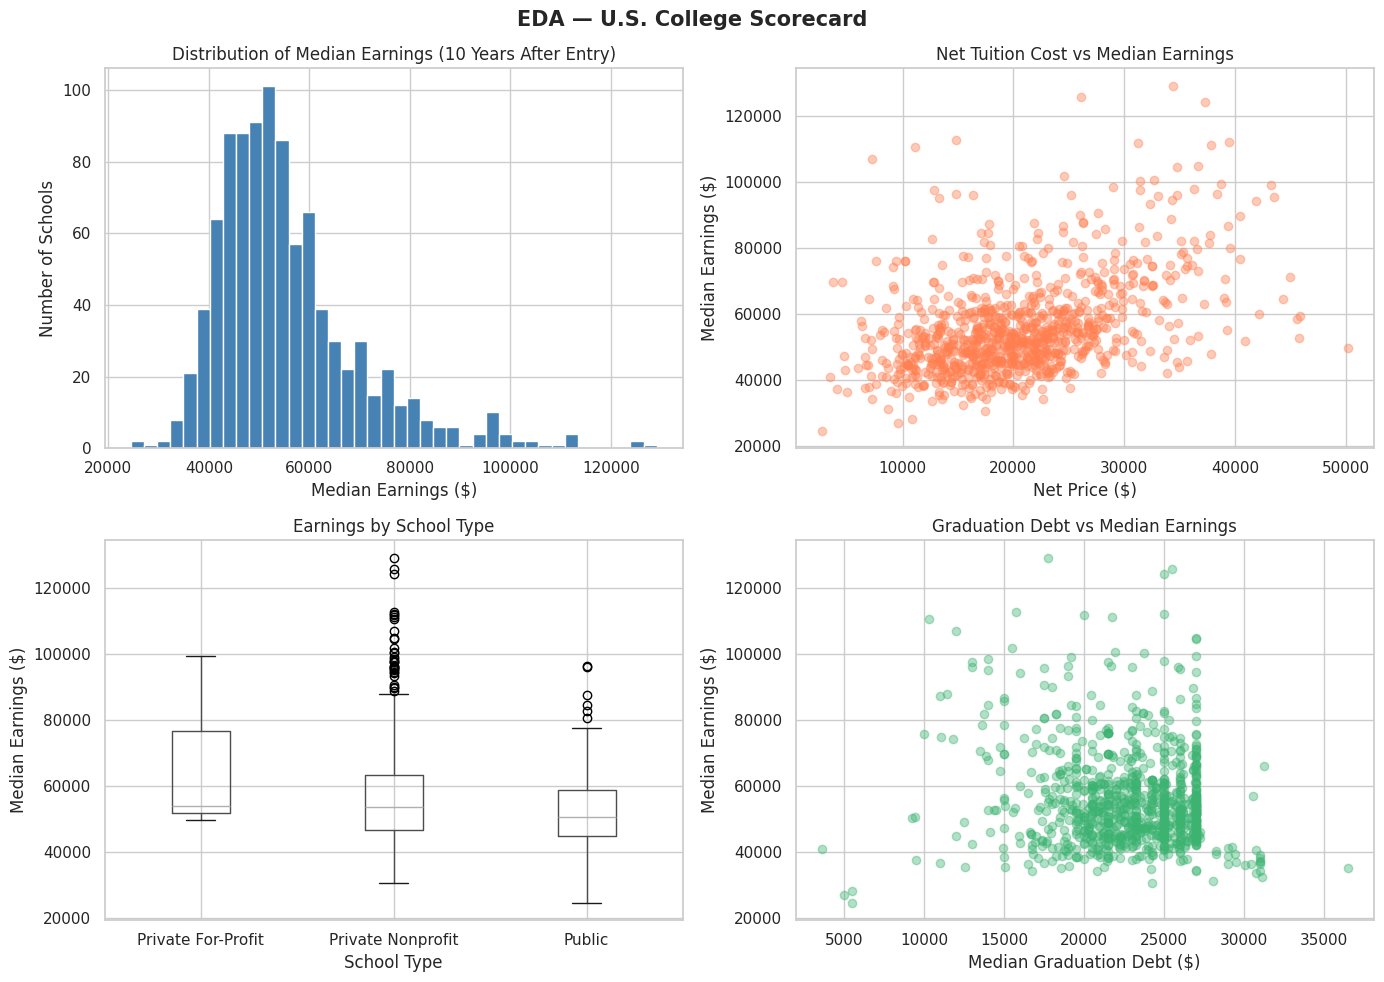

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of earnings
axes[0, 0].hist(df_clean[TARGET], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Median Earnings (10 Years After Entry)')
axes[0, 0].set_xlabel('Median Earnings ($)')
axes[0, 0].set_ylabel('Number of Schools')

# Plot 2: Net price vs earnings
axes[0, 1].scatter(df_clean['NET_PRICE'], df_clean[TARGET], alpha=0.4, color='coral')
axes[0, 1].set_title('Net Tuition Cost vs Median Earnings')
axes[0, 1].set_xlabel('Net Price ($)')
axes[0, 1].set_ylabel('Median Earnings ($)')

# Plot 3: Earnings by school type
school_types = {1: 'Public', 2: 'Private Nonprofit', 3: 'Private For-Profit'}
df_clean['SCHOOL_TYPE'] = df_clean['CONTROL'].map(school_types)
df_clean.boxplot(column=TARGET, by='SCHOOL_TYPE', ax=axes[1, 0])
plt.sca(axes[1, 0])
plt.title('Earnings by School Type')
axes[1, 0].set_xlabel('School Type')
axes[1, 0].set_ylabel('Median Earnings ($)')

# Plot 4: Debt vs earnings
axes[1, 1].scatter(df_clean['GRAD_DEBT_MDN_SUPP'], df_clean[TARGET], alpha=0.4, color='mediumseagreen')
axes[1, 1].set_title('Graduation Debt vs Median Earnings')
axes[1, 1].set_xlabel('Median Graduation Debt ($)')
axes[1, 1].set_ylabel('Median Earnings ($)')

plt.suptitle('EDA — U.S. College Scorecard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

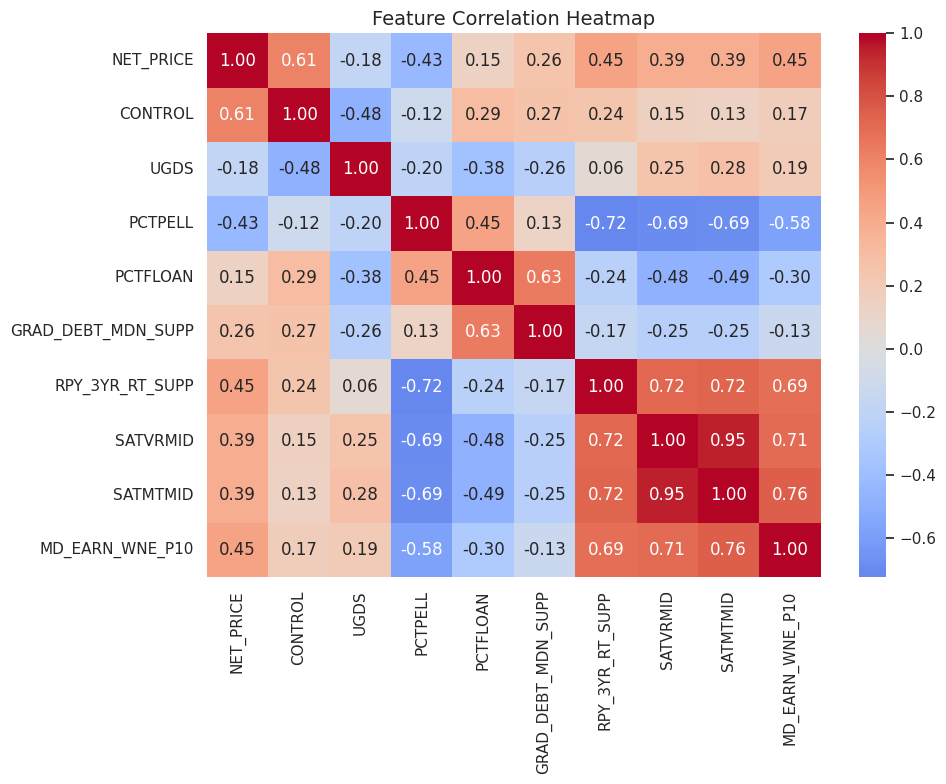

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Prepare Data for Modeling

In [13]:
X = df_clean[FEATURES].values
y = df_clean[TARGET].values

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit only on train

print(f'Training set:  {X_train.shape[0]} schools')
print(f'Test set:      {X_test.shape[0]} schools')
print('Data ready for modeling!')

Training set:  760 schools
Test set:      190 schools
Data ready for modeling!


## 6. Model 1 — Linear Regression (Baseline)
As covered in **W8: Linear Regression** — minimizing MSE loss via gradient descent.

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
cv_lr   = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')

print('=== Linear Regression Results ===')
print(f'MAE:              ${mae_lr:,.0f}')
print(f'RMSE:             ${rmse_lr:,.0f}')
print(f'R² (test set):     {r2_lr:.4f}')
print(f'R² (5-fold CV):    {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print('\nFeature Coefficients:')
print(coef_df.to_string(index=False))

=== Linear Regression Results ===
MAE:              $6,596
RMSE:             $8,512
R² (test set):     0.5868
R² (5-fold CV):    0.6325 +/- 0.0318

Feature Coefficients:
           Feature  Coefficient
          SATMTMID 10142.418069
   RPY_3YR_RT_SUPP  4877.807823
          SATVRMID -2867.289160
         NET_PRICE  2358.507976
           PCTPELL  1301.230086
              UGDS  1023.829367
GRAD_DEBT_MDN_SUPP   382.831626
          PCTFLOAN  -147.985508
           CONTROL  -120.786149


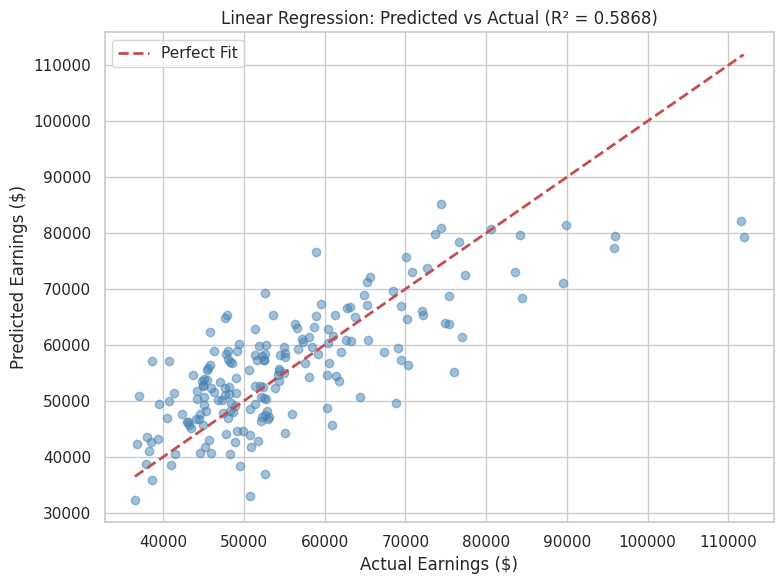

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Earnings ($)')
plt.ylabel('Predicted Earnings ($)')
plt.title(f'Linear Regression: Predicted vs Actual (R² = {r2_lr:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('lr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model 2 — Feedforward Neural Network (FFN)

In [16]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

class FFN(nn.Module):
    def __init__(self, input_dim):
        super(FFN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),       # Non-linear activation
            nn.Dropout(0.2), # Regularization
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Output: predicted salary
        )
    def forward(self, x):
        return self.network(x)

model     = FFN(input_dim=len(FEATURES))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

FFN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 11,649


In [17]:
# Train via Backpropagation
EPOCHS = 150
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()             # Reset gradients
        y_pred = model(X_batch)           # Forward pass
        loss = criterion(y_pred, y_batch) # MSE loss
        loss.backward()                   # Backpropagation
        optimizer.step()                  # Update weights
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.4f}')

print('FFN Training complete!')

Epoch [25/150]  Loss: 231385303.3333
Epoch [50/150]  Loss: 155101901.0000
Epoch [75/150]  Loss: 119437655.3333
Epoch [100/150]  Loss: 102324187.0000
Epoch [125/150]  Loss: 96387338.0000
Epoch [150/150]  Loss: 88344329.6667
FFN Training complete!


In [18]:
# =====================================================================
# Save trained models and scaler to disk
# =====================================================================

import pickle
import torch

# Save FFN weights
torch.save(model.state_dict(), 'ffn_model.pt')

# Save scaler (needed to transform new inputs the same way)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save Linear Regression model
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print('Models saved: ffn_model.pt, scaler.pkl, lr_model.pkl')

Models saved: ffn_model.pt, scaler.pkl, lr_model.pkl


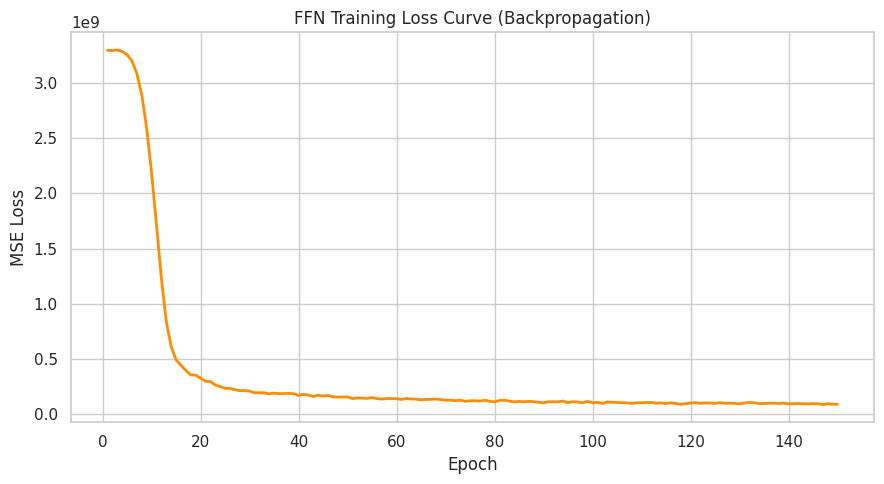

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS+1), train_losses, color='darkorange', lw=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('FFN Training Loss Curve (Backpropagation)')
plt.tight_layout()
plt.savefig('ffn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
model.eval()
with torch.no_grad():
    y_pred_ffn = model(X_test_t).numpy().flatten()

mae_ffn  = mean_absolute_error(y_test, y_pred_ffn)
rmse_ffn = np.sqrt(mean_squared_error(y_test, y_pred_ffn))
r2_ffn   = r2_score(y_test, y_pred_ffn)

print('=== FFN Results ===')
print(f'MAE:              ${mae_ffn:,.0f}')
print(f'RMSE:             ${rmse_ffn:,.0f}')
print(f'R² (test set):     {r2_ffn:.4f}')

=== FFN Results ===
MAE:              $6,142
RMSE:             $8,108
R² (test set):     0.6251


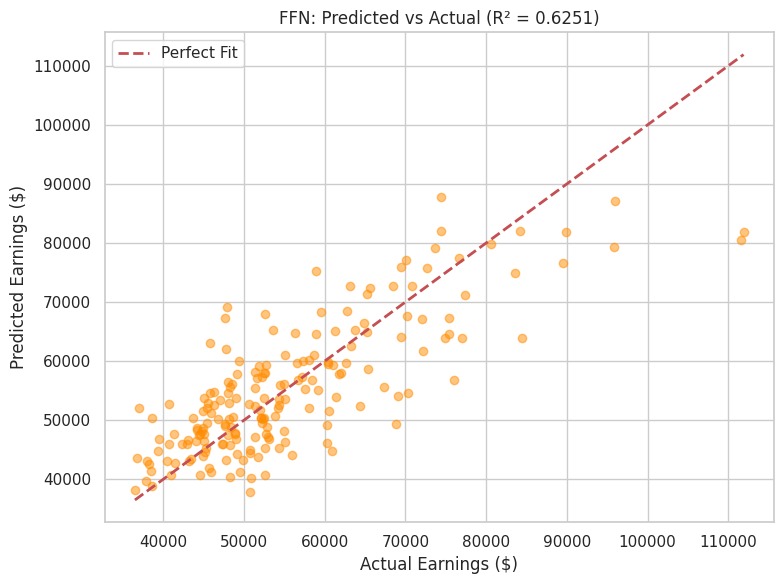

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ffn, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Earnings ($)')
plt.ylabel('Predicted Earnings ($)')
plt.title(f'FFN: Predicted vs Actual (R² = {r2_ffn:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('ffn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Comparison

====== MODEL COMPARISON ======
                     Model MAE ($) RMSE ($) R² Score
         Linear Regression   6,596    8,512   0.5868
Feedforward Neural Network   6,142    8,108   0.6251


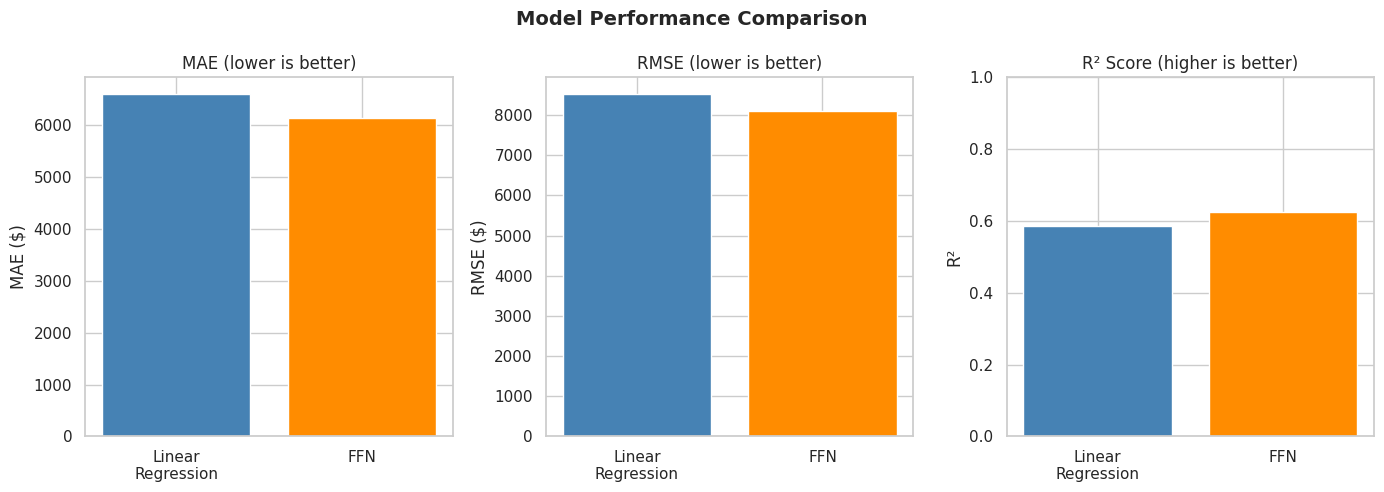

In [22]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Feedforward Neural Network'],
    'MAE ($)':  [f'{mae_lr:,.0f}',   f'{mae_ffn:,.0f}'],
    'RMSE ($)': [f'{rmse_lr:,.0f}',  f'{rmse_ffn:,.0f}'],
    'R² Score': [f'{r2_lr:.4f}',     f'{r2_ffn:.4f}']
})
print('====== MODEL COMPARISON ======')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = ['Linear\nRegression', 'FFN']
colors = ['steelblue', 'darkorange']

axes[0].bar(models, [mae_lr,  mae_ffn],  color=colors)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE ($)')

axes[1].bar(models, [rmse_lr, rmse_ffn], color=colors)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE ($)')

axes[2].bar(models, [r2_lr,   r2_ffn],   color=colors)
axes[2].set_title('R² Score (higher is better)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Findings

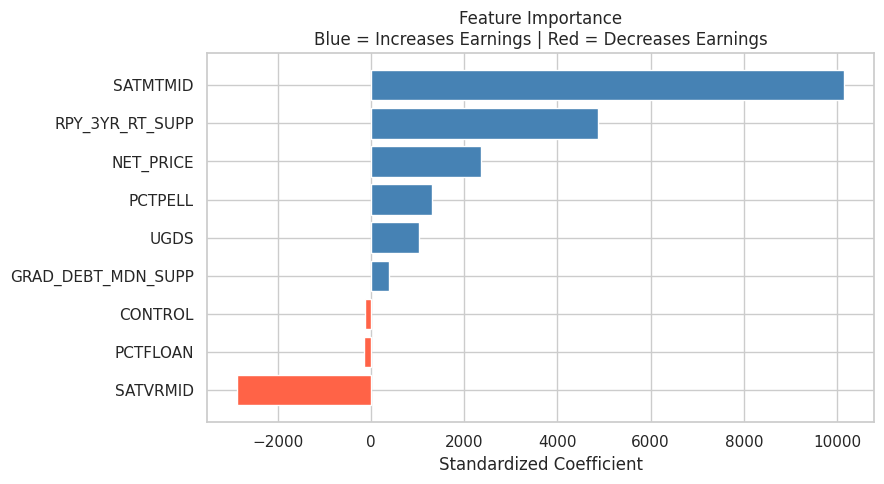

In [23]:
# Feature importance
plt.figure(figsize=(9, 5))
coef_sorted = coef_df.sort_values('Coefficient')
bar_colors = ['tomato' if c < 0 else 'steelblue' for c in coef_sorted['Coefficient']]
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=bar_colors)
plt.xlabel('Standardized Coefficient')
plt.title('Feature Importance\nBlue = Increases Earnings | Red = Decreases Earnings')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print('=== Top 10 Highest Earning Schools ===')
print(df_clean[['INSTNM', TARGET, 'NET_PRICE', 'SCHOOL_TYPE']]
      .sort_values(TARGET, ascending=False).head(10).to_string(index=False))

print('\n=== Top 10 Lowest Earning Schools ===')
print(df_clean[['INSTNM', TARGET, 'NET_PRICE', 'SCHOOL_TYPE']]
      .sort_values(TARGET, ascending=True).head(10).to_string(index=False))

=== Top 10 Highest Earning Schools ===
                                                 INSTNM  MD_EARN_WNE_P10  NET_PRICE       SCHOOL_TYPE
University of Health Sciences and Pharmacy in St. Louis         129137.0    34371.0 Private Nonprofit
         Albany College of Pharmacy and Health Sciences         125798.0    26073.0 Private Nonprofit
                                       MCPHS University         124126.0    37288.0 Private Nonprofit
                             University of Pennsylvania         112761.0    14851.0 Private Nonprofit
                                     Bentley University         111896.0    39437.0 Private Nonprofit
                                         Babson College         111604.0    31267.0 Private Nonprofit
                             Carnegie Mellon University         111064.0    37846.0 Private Nonprofit
                                   Princeton University         110433.0    11080.0 Private Nonprofit
                                    Stanfor

#10. Agent
The agent utilizes the Anthropic API for access to Claude. In order for the tool to work, you must set up your Anthropic API key (https://platform.claude.com/) as specified below.

For Colab:


1.   Open secrets tab
2.   Add new secret with name: ANTHROPIC_API_KEY and add API key to value
3.  Check access box

For local implementation:

1.   Create .env file
2.   add the following: ANTHROPIC_API_KEY = your_api_key





In [25]:

# =====================================================================
# Frontend Setup — Gradio UI + Claude API Integration
# =====================================================================

!pip install gradio anthropic -q

import gradio as gr
import anthropic
import torch
import pickle
import os

# Get API key — tries Colab Secrets first, then environment variable
try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
except (ImportError, Exception):
    ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')

if not ANTHROPIC_API_KEY:
    raise ValueError(
        "ANTHROPIC_API_KEY not found. In Colab: click the key icon in "
        "the left sidebar and add it as a secret. Locally: set it as an "
        "environment variable or in a .env file."
    )

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

# Verify models are loaded (should already be in memory from earlier cells)
# If running this cell standalone, load them from disk:
try:
    model  # FFN should already be defined
    scaler # scaler should already be defined
    lr     # lr should already be defined
    print('Using models already in memory.')
except NameError:
    print('Loading saved models from disk...')
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import StandardScaler

    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('lr_model.pkl', 'rb') as f:
        lr = pickle.load(f)
    model = FFN(input_dim=9)
    model.load_state_dict(torch.load('ffn_model.pt'))
    model.eval()
    print('Models loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 9.4 MB/s eta 0:00:00
Using models already in memory.


In [26]:
# =====================================================================
# Prediction + LLM Analysis Pipeline
# =====================================================================

def predict_and_advise(school_name, net_price, school_type_label,
                       ugds, pctpell, pctfloan,
                       grad_debt, rpy_rate, satvr, satmt):
    """
    Takes school stats from the UI, runs them through our trained FFN
    and Linear Regression models, then asks Claude to analyze the results.
    Returns 4 outputs for the Gradio interface.
    """

    # Convert school type label back to numeric code for the model
    control_map = {'Public': 1, 'Private Nonprofit': 2, 'Private For-Profit': 3}
    control = control_map[school_type_label]

    # Build feature vector in the SAME order the model was trained on
    # FEATURES = ['NET_PRICE', 'CONTROL', 'UGDS', 'PCTPELL', 'PCTFLOAN',
    #             'GRAD_DEBT_MDN_SUPP', 'RPY_3YR_RT_SUPP', 'SATVRMID', 'SATMTMID']
    feature_vector = [[net_price, control, ugds, pctpell, pctfloan,
                       grad_debt, rpy_rate, satvr, satmt]]

    # Scale using the fitted scaler (important - inputs must be scaled same as training)
    scaled_input = scaler.transform(feature_vector)

    # FFN prediction
    input_tensor = torch.tensor(scaled_input, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        ffn_salary = model(input_tensor).item()

    # Linear Regression prediction
    lr_salary = lr.predict(scaled_input)[0]

    # Calculate difference
    diff = ffn_salary - lr_salary

    # Build the prompt for Claude
    prompt = f"""You are a college advisor analyzing an ML model's prediction.

School: {school_name} ({school_type_label})

Institutional statistics:
- Net tuition price: ${net_price:,.0f}
- Undergraduate enrollment: {int(ugds):,}
- % of students on Pell grants: {pctpell*100:.0f}%
- % of students on federal loans: {pctfloan*100:.0f}%
- Median graduation debt: ${grad_debt:,.0f}
- 3-year loan repayment rate: {rpy_rate*100:.0f}%
- SAT math midpoint: {int(satmt)}
- SAT reading midpoint: {int(satvr)}

Our Feedforward Neural Network (trained on 950 U.S. institutions from \
the Department of Education College Scorecard) predicts median earnings \
10 years after enrollment: ${ffn_salary:,.0f}

In 3-4 concise sentences, provide:
1. A brief interpretation of this salary prediction given the school's profile
2. Whether this represents a good return on investment relative to the tuition cost
3. 2-3 career paths that are common for graduates of this type of school

Be direct and practical — this is for a prospective student making a real decision."""

    # Call Claude API
    try:
        message = client.messages.create(
            model="claude-opus-4-7",
            max_tokens=400,
            messages=[{"role": "user", "content": prompt}]
        )
        analysis = message.content[0].text
    except Exception as e:
        analysis = f"(AI analysis unavailable: {str(e)})"

    return (
        f"${ffn_salary:,.0f}",
        f"${lr_salary:,.0f}",
        f"{'+' if diff >= 0 else ''}${diff:,.0f}",
        analysis
    )

In [27]:
# =====================================================================
# Launch Gradio Interface
# =====================================================================

demo = gr.Interface(
    fn=predict_and_advise,
    inputs=[
        gr.Textbox(label="School Name", value="UNC Chapel Hill"),
        gr.Number(label="Net Tuition Price ($/yr)", value=12000),
        gr.Radio(
            choices=["Public", "Private Nonprofit", "Private For-Profit"],
            label="School Type",
            value="Public"
        ),
        gr.Number(label="Undergraduate Enrollment", value=19000),
        gr.Slider(0, 1, step=0.01, label="% on Pell Grants", value=0.32),
        gr.Slider(0, 1, step=0.01, label="% on Federal Loans", value=0.48),
        gr.Number(label="Median Graduation Debt ($)", value=21000),
        gr.Slider(0, 1, step=0.01, label="3-Year Repayment Rate", value=0.61),
        gr.Number(label="SAT Reading Midpoint", value=630),
        gr.Number(label="SAT Math Midpoint", value=650),
    ],
    outputs=[
        gr.Textbox(label="💰 FFN Predicted Salary (10 yrs post-enrollment)"),
        gr.Textbox(label="📊 Linear Regression Baseline"),
        gr.Textbox(label="📈 FFN vs Linear Regression Difference"),
        gr.Textbox(label="🤖 Claude AI Career Analysis", lines=8),
    ],
    title="🎓 College Salary Advisor",
    description=(
        "Enter a school's statistics to get an ML-powered salary prediction "
        "and AI-generated career insights. Combines a Feedforward Neural "
        "Network (trained on U.S. College Scorecard data) with Claude "
        "(Anthropic) for natural language analysis. — COMP 560 Final Project"
    ),
    examples=[
        ["UNC Chapel Hill", 12000, "Public", 19000, 0.32, 0.48, 21000, 0.61, 630, 650],
        ["Harvard University", 18000, "Private Nonprofit", 7200, 0.16, 0.10, 14000, 0.94, 730, 750],
        ["University of Puerto Rico", 3000, "Public", 10000, 0.78, 0.25, 8000, 0.28, 480, 510],
    ],
    flagging_mode="never",
)

# Launch with public URL (valid 72 hours)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9aef7599fc8b722b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
